In [13]:
import sys
import os
import h5py
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

#from src import io, visualizations, timesync
from src import loader, visualizations as vis, timesync
import nre.io as io


import xarray as xr
import seaborn as sns


1. set experiment id and base directory
2. Run io.get_base_path for raw and processed directories
3. extract scope timestamps
4. load signal and timestamps into xarray
5.

In [8]:
raw_path =  loader.get_base_path('fly09_win01_trial-001', 'raw', base_dir='/Volumes/AhmedLab/princess/data/pIP10')
processed_path = loader.get_base_path('fly09_win01_trial-001 - v1', 'processed', base_dir='/Volumes/AhmedLab/princess/data/pIP10')
cluster_labels, signal = loader.load_clusters(processed_path)
# scope_timestamps = timesync.extract_scope_timestamps(raw_path)
# scope_fr, camera_fr, brain_dim = io.load_acquisition_params(processed_path)

In [19]:
cluster_labels.shape
brain_dim = [512, 512, 11]

In [10]:
with h5py.File(f'{processed_path}scope_timestamps.h5', 'w') as hf:
    hf.create_dataset('my_data', data=scope_timestamps)

In [13]:
def convert_frametimestamps_to_datetime(timestamps_dataframe):
    # this selects the first slice fo teh volume to use as our timestamp
    t0 = np.datetime64('2025-01-01T00:00:00')
    volume_deltas = np.round(timestamps_dataframe[::11]).astype('<m8[ms]')
    dt_timestamps = t0 + volume_deltas
    return dt_timestamps

timestamps = convert_frametimestamps_to_datetime(scope_timestamps)
print(timestamps)

                            0
0     2025-01-01 00:00:00.067
11    2025-01-01 00:00:00.498
22    2025-01-01 00:00:00.930
33    2025-01-01 00:00:01.362
44    2025-01-01 00:00:01.794
...                       ...
30514 2025-01-01 00:19:57.974
30525 2025-01-01 00:19:58.406
30536 2025-01-01 00:19:58.838
30547 2025-01-01 00:19:59.269
30558 2025-01-01 00:19:59.701

[2779 rows x 1 columns]


In [9]:
# transform signal to xarray
signal_xr = xr.DataArray(
    data=signal,
    dims=['zposs', 'roi', 'time'],
    coords={'time': timestamps.squeeze()}
)


KeyboardInterrupt



0 [8, 100]
1 [8, 20]


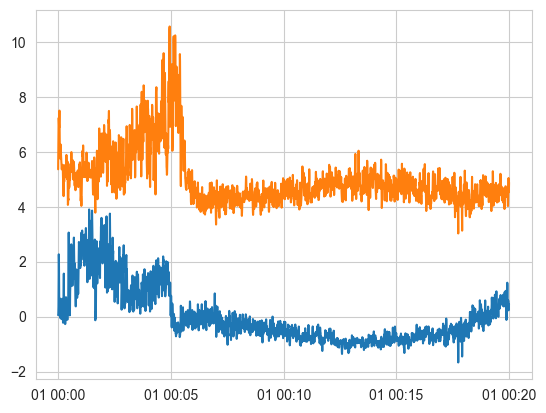

In [24]:
rois = [[8,100],[8,20]]
# print(rois[0][1])
yshift=5
for index, roi in enumerate(rois):
    print(index, roi)
    to_plot = signal_xr.isel(zposs=roi[0], roi=roi[1])
    plt.plot(signal_xr.coords['time'], to_plot+(yshift*index))

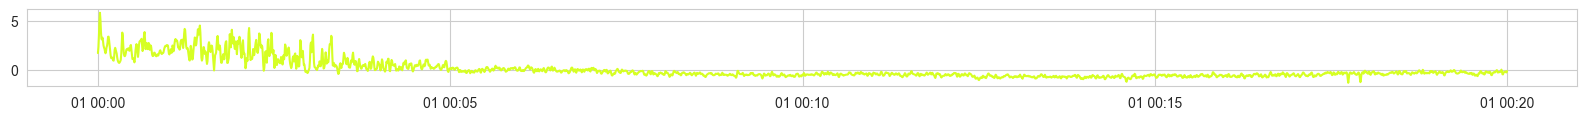

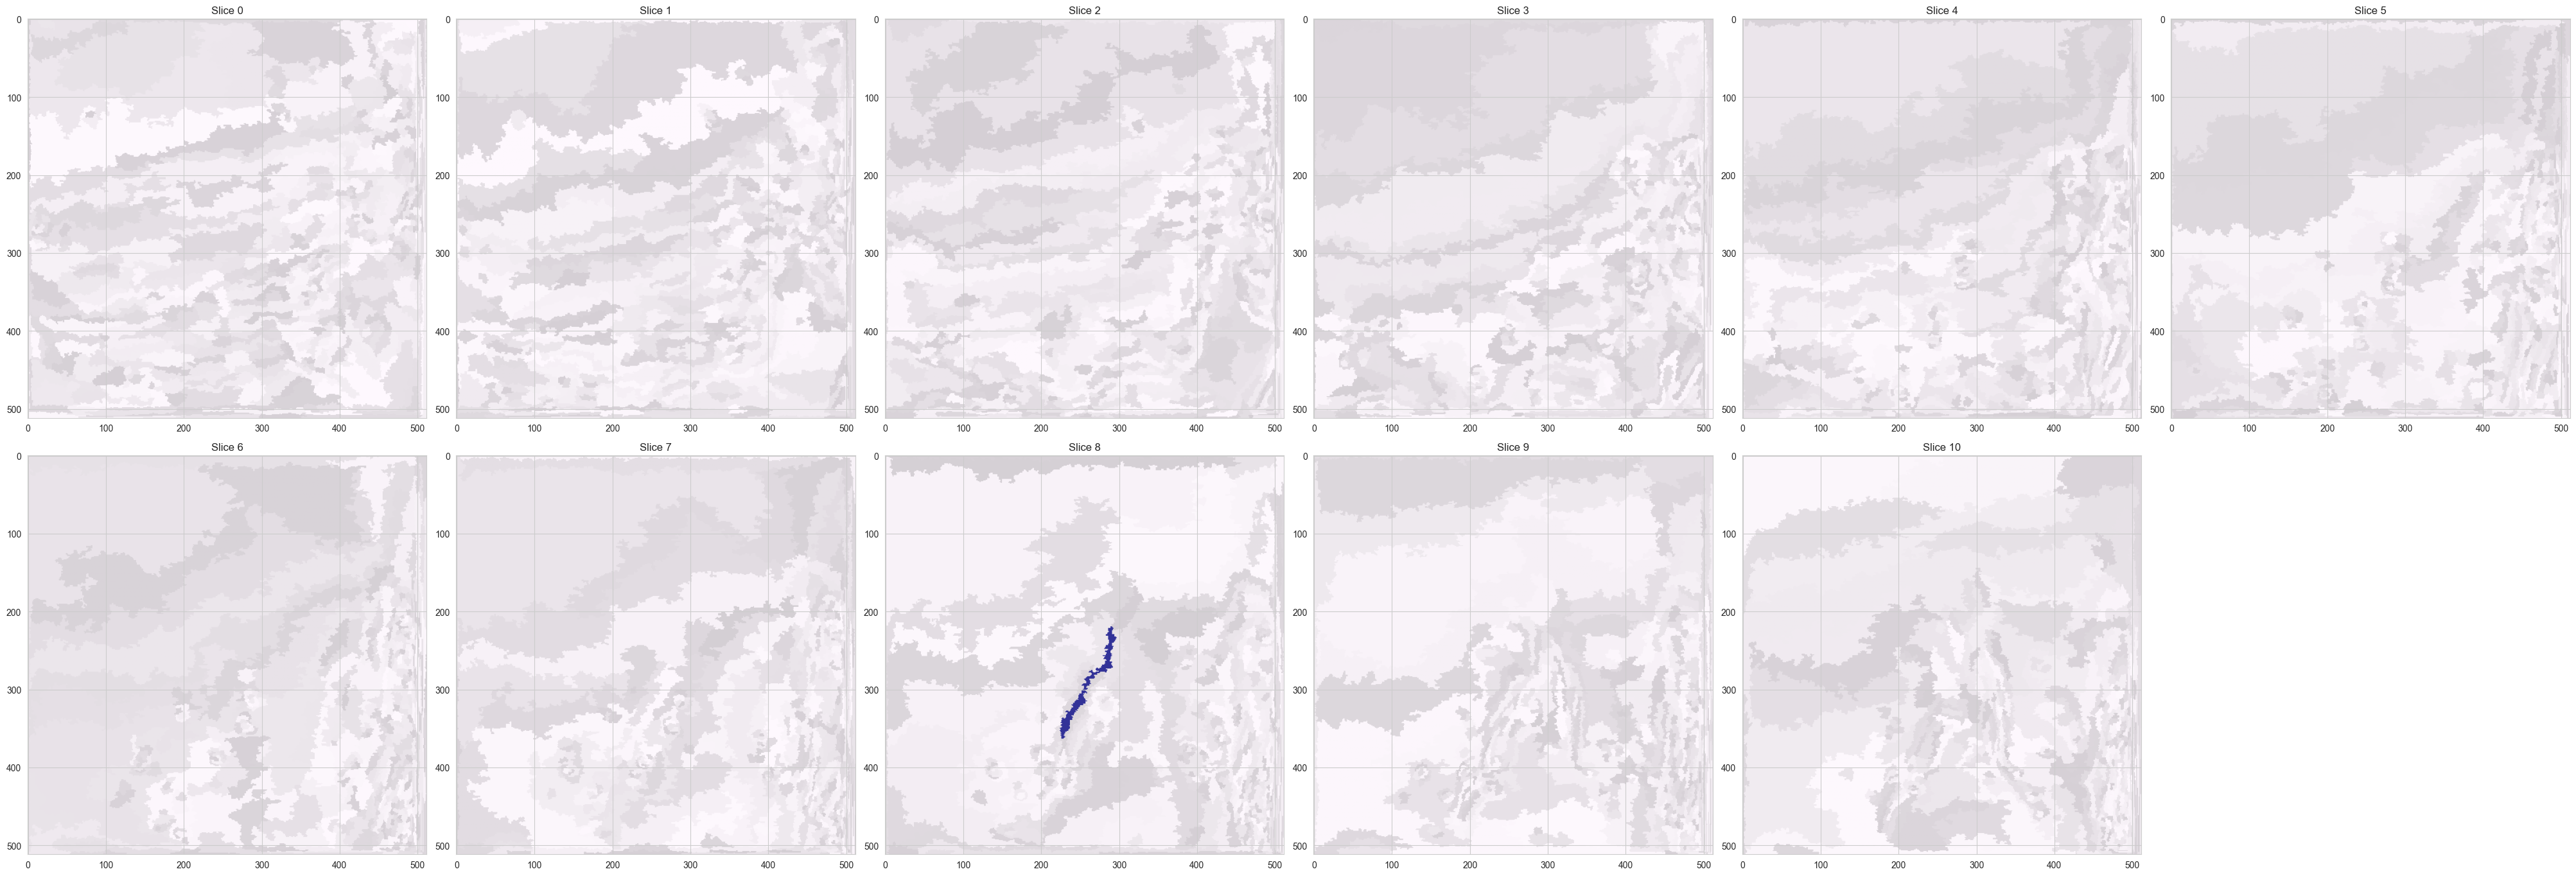

In [35]:
rois = [[8, x] for x in range(13,14)]
visualizations.plot_zscored_activity(rois, signal_xr)
visualizations.plot_spatial_location(rois, cluster_labels,brain_dimensions=brain_dim)

[37.09803184 28.37407689 13.49525241  7.11210989  4.57328898  3.65753299
  1.93491649  1.64744945  1.11378809  0.99355297]


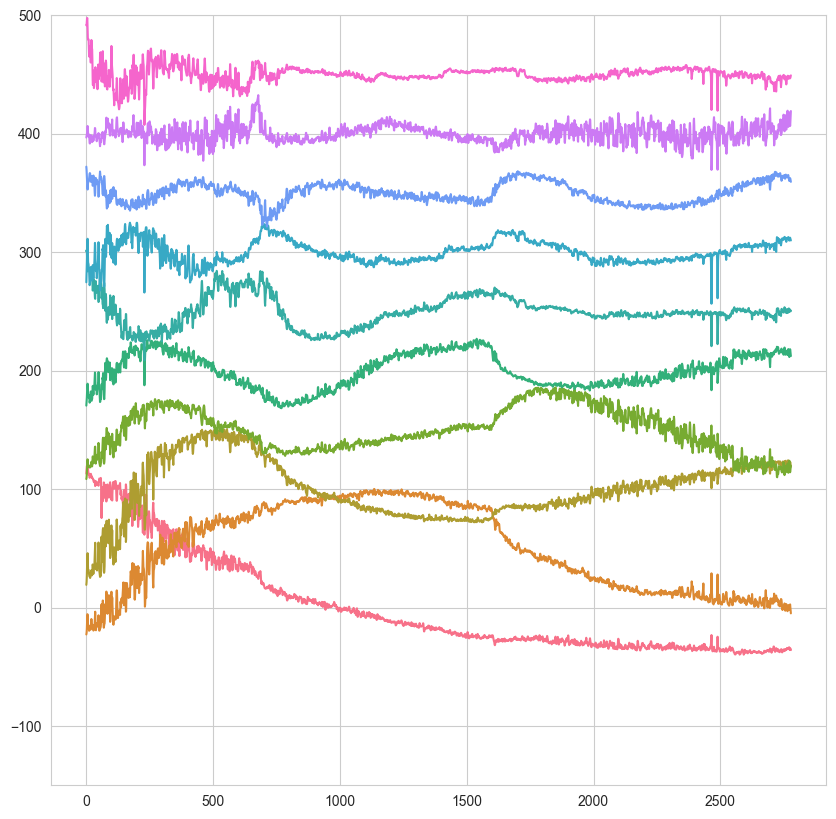

In [38]:
to_pca = signal_xr.stack(poss=['zposs', 'roi'])
to_pca -= to_pca.mean(dim='time')
to_pca = to_pca.dropna(dim='time', how='any')
pca = PCA(n_components=10)

# fit my data to the 50 PCA components
all_transformed = pca.fit_transform(to_pca.transpose('time', 'poss'))
print(pca.explained_variance_ / np.sum(pca.explained_variance_) * 100)

fig, ax = plt.subplots(figsize=(10, 10))
color_list = sns.color_palette('husl', n_colors=10)
yshift = 50
ax.set_ylim(-150, 500)
for idx, ind_cluster in enumerate(all_transformed.T):
    ax.plot(ind_cluster + (idx * yshift), color=color_list[idx])

In [11]:
 #load fictrac data
import glob
from scipy.signal import savgol_filter
from src import correlations
dat_file = glob.glob(f'{processed_path}/*.dat')[0]
fictrac_data = pd.DataFrame(pd.read_csv(dat_file, header=None))
camera_framerate = 170
win_size = int(.5 * camera_framerate)
inst_speed = np.rad2deg(fictrac_data[18])




In [ ]:
from src import correlations as cr

def pull_fictrac_speed(dat_file, camera_framerate = 170, smoothing_window_s = 0.5):
    dat_dataframe = pd.DataFrame(pd.read_csv(dat_file, header=None))
    inst_speed = np.rad2deg(dat_dataframe[18])

    window_size = int(smoothing_window_s * camera_framerate)



In [128]:
from scipy.interpolate import interp1d
def fill_missing(Y, kind="linear"):
    """
    Fills missing values independently along each dimension after the first.
    Usefull for ndimensional arrays with time at dim0, to fill missing time
    samples.
    """

    # Store initial shape.
    initial_shape = Y.shape

    # Flatten after first dim.
    Y = Y.reshape((initial_shape[0], -1))

    # Interpolate along each slice.
    for i in range(Y.shape[-1]):
        y = Y[:, i]
        # print(i, np.all(np.isnan(y)))
        if np.all(np.isnan(y)):
            print('All nan, cant interpolate. Leaving nans unchanged')
            continue

        # Build interpolant.
        x = np.flatnonzero(~np.isnan(y))
        f = interp1d(x, y[x], kind=kind, fill_value=np.nan, bounds_error=False)

        # Fill missing
        xq = np.flatnonzero(np.isnan(y))
        y[xq] = f(xq)

        # Fill leading or trailing NaNs with the nearest non-NaN values
        mask = np.isnan(y)
        y[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask),
                            y[~mask])

        # Save slice
        Y[:, i] = y

    # Restore to initial shape.
    Y = Y.reshape(initial_shape)

    return Y


42


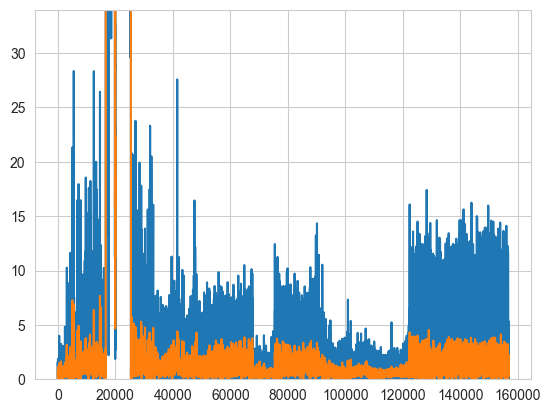

In [24]:
plt.plot(inst_speed)
plt.ylim(0, np.std(inst_speed))
np.median(inst_speed)
win_size = int(.25 * camera_framerate)
print(win_size)
speed_smoothed = savgol_filter(inst_speed, win_size, 3)
plt.plot(speed_smoothed)
# behavior_downsampled = fill_missing(behavior_downsampled)
# for val in

In [12]:
slow_signal = np.array(signal_xr.coords['time'])
fast_signal = np.array(inst_speed)
print(len(slow_signal), len(fast_signal))

slow = slow_signal
fast = fast_signal

max_divider = fast.shape[0] // slow.shape[0]
fast_cut = fast[:slow.shape[0] * max_divider]  # cut excess behavior data
fast_reshaped = np.reshape(fast_cut, (slow.shape[0], -1))
fast_downsample = np.mean(fast_reshaped, axis=1)
print(fast_downsample.shape[0], slow.shape[0])

behavior_downsampled = fast_downsample
# plt.plot(behavior_downsampled)
# for ind, val in enumerate(behavior_downsampled):
#     if behavior_downsampled[ind] < 3:
#         behavior_downsampled[ind] = np.nan()
# behavior_downsampled = savgol_filter(behavior_downsampled, win_size, 3)

behavior_downsampled[behavior_downsampled > 5] = np.nan
behavior_downsampled = savgol_filter(behavior_downsampled, win_size, 3)
behavior_downsampled = fill_missing(behavior_downsampled)
plt.plot(behavior_downsampled)
# plt.ylim(-10,10)

NameError: name 'signal_xr' is not defined

In [130]:
from scipy.stats import pearsonr

# correlation_array = corr.pearson_analysis()

pearson_array = []
to_correlate = signal_xr.stack(signal=['zposs', 'roi'])
# print(to_correlate)
# loop over every signal trace
for a in range(len(to_correlate['signal'])):
    # if a < 10:
        # print(to_correlate.isel(signal=a))
        # corr = pearsonr(to_correlate.isel(signal=a), to_correlate.isel(signal=a)).statistic

    # corr = pearsonr(to_correlate.isel(signal=a), to_correlate.isel(signal=0)).statistic
    # ind_signal = np.array(to_correlate.isel(signal=a))
    # print(len(ind_signal), len(behavior_downsampled))
    corr = pearsonr(to_correlate.isel(signal=a), behavior_downsampled).statistic

    pearson_array.append(corr)
print(len(pearson_array))

5500


In [131]:
pearson_array = np.reshape(pearson_array, (11,500))
print(pearson_array.shape)



corr_array = []
for slice_idx, clusters in enumerate(cluster_labels):
    # for each slice initialize an array
    # for each v
    for id in cluster_labels[slice_idx]:
        corr_value = pearson_array[slice_idx, id]
        # print(id, corr_value)
        # np.append(corr_array, corr_value)
        corr_array.append(corr_value)
corr_array = np.array(corr_array).reshape(brain_dim[2],brain_dim[0], brain_dim[1])
print(corr_array.shape)

(11, 500)
(11, 512, 512)


In [132]:
from matplotlib import colors

12


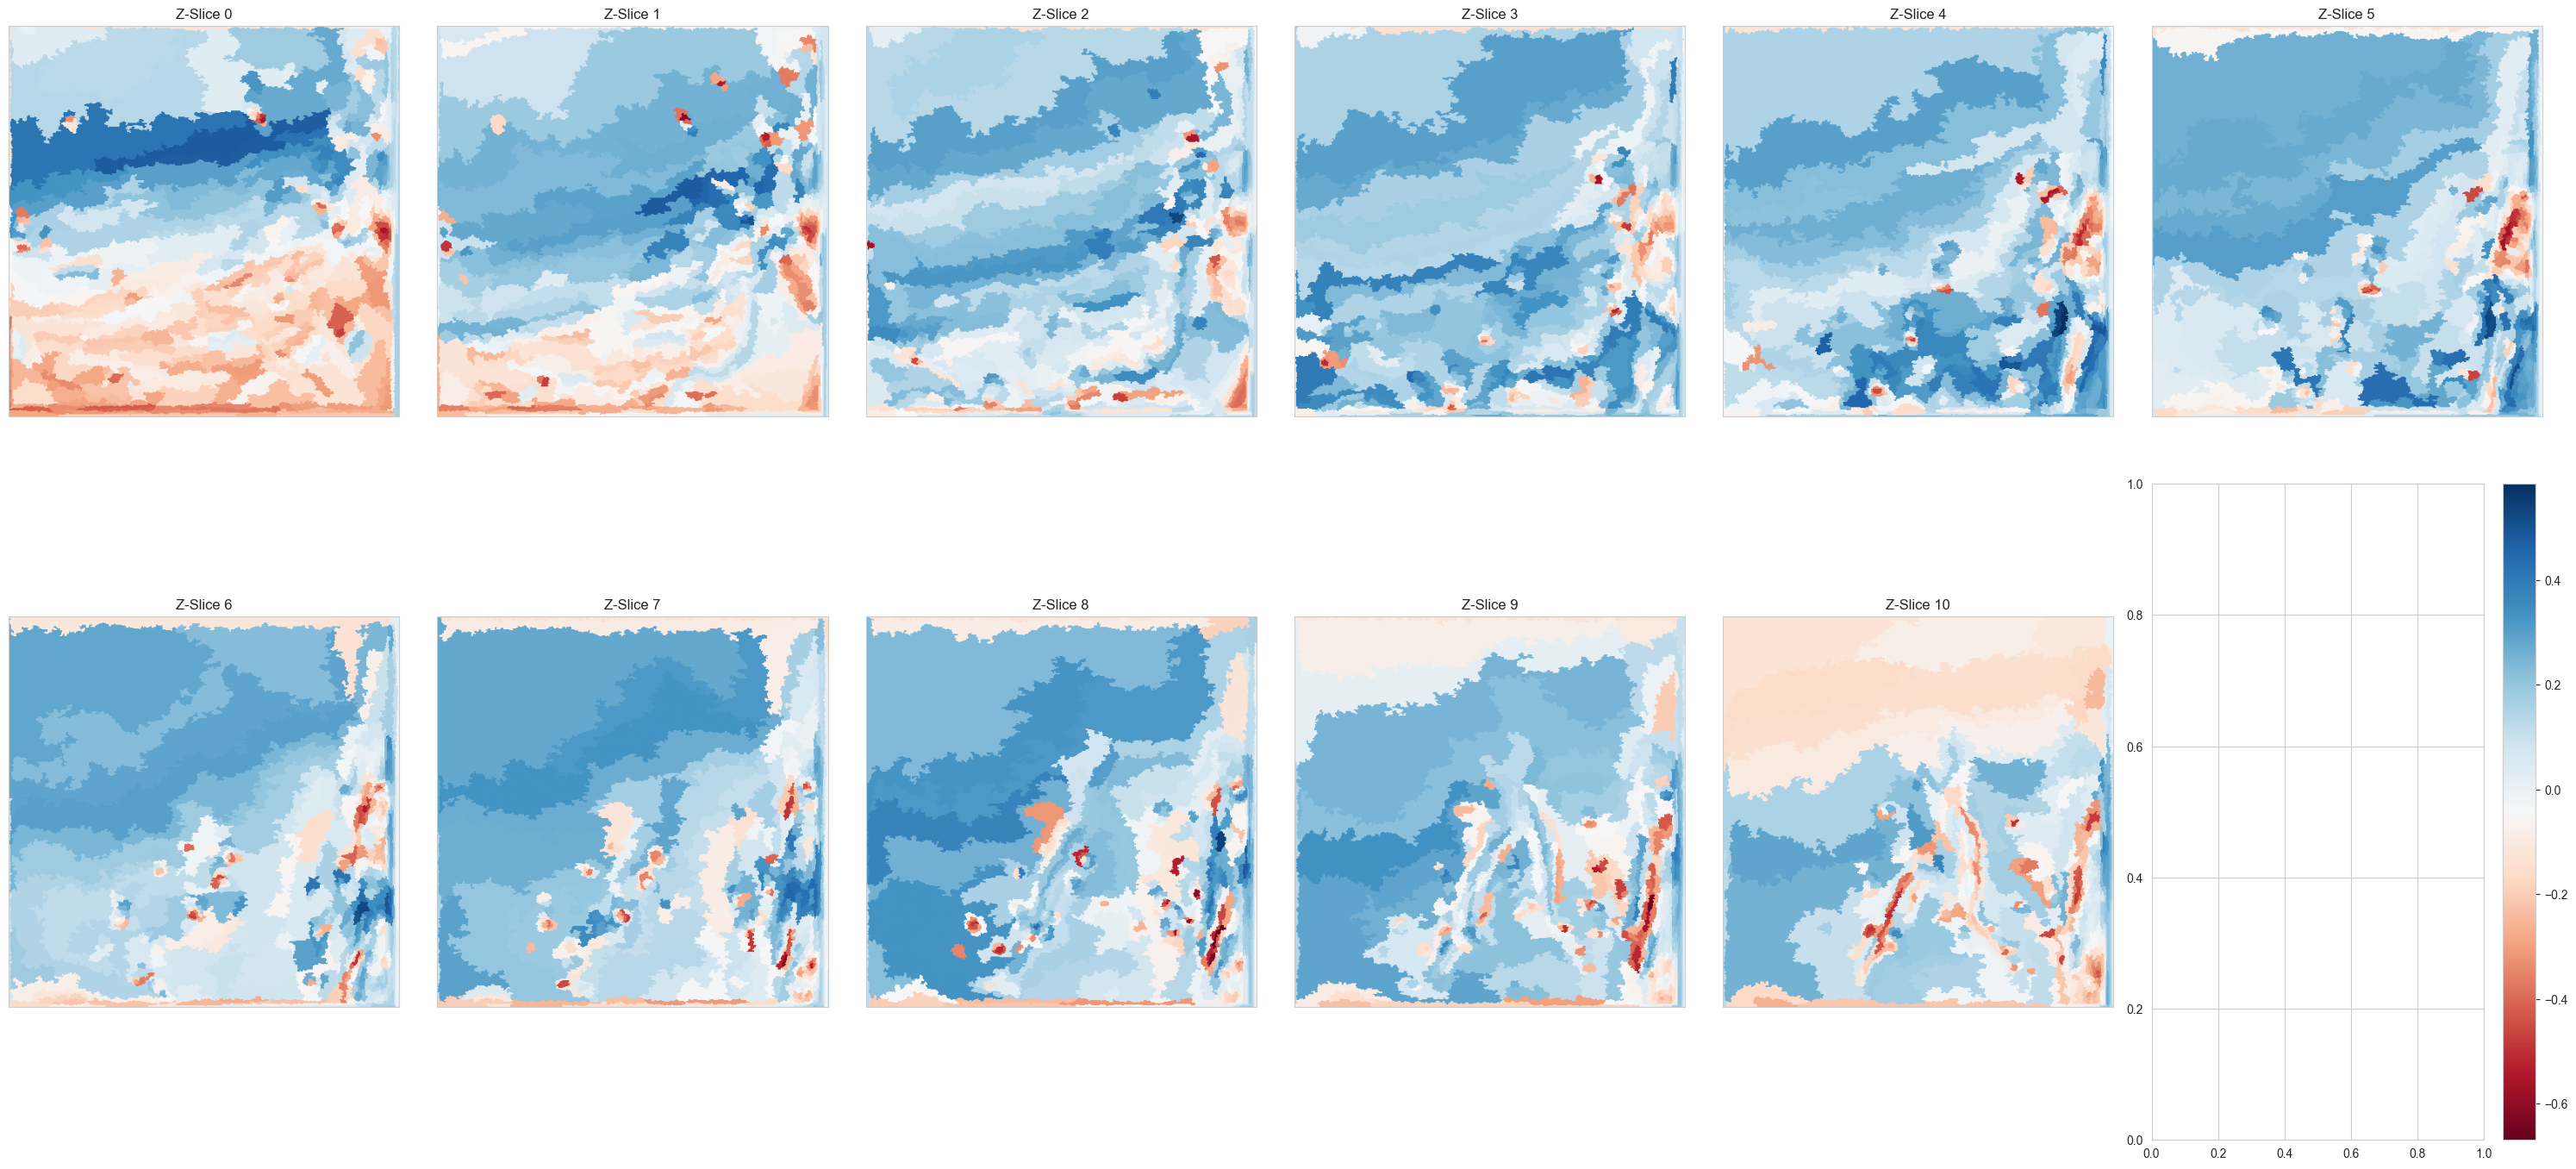

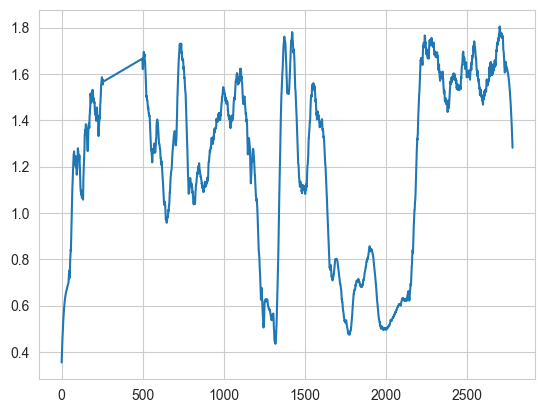

In [133]:
fig, axes = plt.subplots(2, 6, figsize=(30, 15)) # (xaxis, yaxis, figure size)
cmap = 'RdBu'
# Flatten the 2D array of axes for easier iteration
axes = axes.flatten()
print(len(axes))
# create a single norm to be shared across all images
norm_all = colors.Normalize(vmin=np.min(corr_array), vmax=np.max(corr_array))
images = []
# Populate each subplot with some sample data
for i, ax in enumerate(axes):
    if i < corr_array.shape[0]:
        images.append(ax.imshow(corr_array[i].T, cmap=cmap, norm=norm_all))
        ax.set_title(f'Z-Slice {i}')
        ax.set_xticks([]) # Hide x-axis ticks for cleaner appearance
        ax.set_yticks([]) # Hide
fig.colorbar(images[0], ax=ax, orientation='vertical', fraction=.1)
plt.tight_layout()
plt.show()

plt.plot(behavior_downsampled)
# plt.ylim(-10,20)